# 02 — Data Understanding, Visualisation, Emissions Calculation and Payload Generation

This notebook starts from the patched CSV files produced by the patch notebook.

It contains:

1. Data loading and understanding
2. Data visualisations
3. Emissions and KPI calculations
4. Requirements-informed payload completeness checks
5. Full payload generation
6. Section-specific payload generation

It does **not** generate `disclosures.csv`, `data_requirements.csv`, or `disclosure_data_map.csv`.

In [1]:
from pathlib import Path
import os
import json
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Django-compatible configuration
# ============================================================
# Django passes these environment variables when executing the notebook:
# - IFRS_PROJECT_ROOT: Django backend root, usually the folder containing manage.py
# - IFRS_DATA_DIR: batch canonical CSV folder
# - IFRS_OUTPUT_DIR: batch payload output folder
# - IFRS_REQUIREMENTS_DIR: static IFRS requirements folder

CURRENT_DIR = Path.cwd()

PROJECT_ROOT = Path(
    os.environ.get("IFRS_PROJECT_ROOT", CURRENT_DIR)
).resolve()

IFRS_DATA_DIR = os.environ.get("IFRS_DATA_DIR")
IFRS_OUTPUT_DIR = os.environ.get("IFRS_OUTPUT_DIR")
IFRS_REQUIREMENTS_DIR = os.environ.get("IFRS_REQUIREMENTS_DIR")
IFRS_ZIP_PATH = os.environ.get("IFRS_ZIP_PATH")

if not IFRS_DATA_DIR:
    raise ValueError(
        "IFRS_DATA_DIR environment variable is required. "
        "It should point to the batch canonical CSV folder."
    )

if not IFRS_OUTPUT_DIR:
    raise ValueError(
        "IFRS_OUTPUT_DIR environment variable is required. "
        "It should point to the batch payload output folder."
    )

DATA_DIR = Path(IFRS_DATA_DIR).resolve()
OUTPUT_DIR = Path(IFRS_OUTPUT_DIR).resolve()

if IFRS_REQUIREMENTS_DIR:
    REQUIREMENTS_DIR = Path(IFRS_REQUIREMENTS_DIR).resolve()
else:
    REQUIREMENTS_DIR = (
        PROJECT_ROOT
        / "data_preparation"
        / "generation_inputs"
        / "ifrs-assets"
        / "IFRS-S1-S2"
        / "2024"
    ).resolve()

if IFRS_ZIP_PATH:
    ZIP_PATH = Path(IFRS_ZIP_PATH).resolve()
else:
    ZIP_PATH = PROJECT_ROOT / "data.zip"

# Backward-compatible names used by the original notebook logic.
RAW_DATA_DIR = DATA_DIR
PATCHED_DATA_DIR = DATA_DIR
DATA_SOURCE = "canonical batch CSVs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BASE_REQUIRED_FILES = {"banks.csv", "financial_summary.csv", "governance.csv", "exposures.csv", "counterparties.csv"}
REQUIRED_BASE_TABLES = {name.replace(".csv", "") for name in BASE_REQUIRED_FILES}

def folder_has_base_csvs(folder: Path) -> bool:
    return folder.exists() and all((folder / name).exists() for name in BASE_REQUIRED_FILES)

REQUIREMENT_FILES = {
    "general_requirements": REQUIREMENTS_DIR / "general_requirements_requirements.json",
    "governance": REQUIREMENTS_DIR / "governance_requirements.json",
    "strategy": REQUIREMENTS_DIR / "strategy_requirements.json",
    "risk_management": REQUIREMENTS_DIR / "risk_management_requirements.json",
    "metrics_targets": REQUIREMENTS_DIR / "metrics_and_targets_requirements.json",
}

REPORTING_YEAR = 2024
COMPARATIVE_YEARS = [2022, 2023]
FLEET_EMISSION_FACTOR_KGCO2_PER_LITRE = 2.67

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("REQUIREMENTS_DIR:", REQUIREMENTS_DIR)
print("Requirement files found:")
for key, path in REQUIREMENT_FILES.items():
    print(f"  {key}: {path.exists()} — {path}")


PROJECT_ROOT: C:\Users\HP\Documents\IFRS-Reporting-api\IFRS-Reporting\IFRS-Reporting\backend
DATA_DIR: C:\Users\HP\Documents\IFRS-Reporting-api\IFRS-Reporting\IFRS-Reporting\backend\media\data_preparation\batches\7123bd3a-948b-44db-8cdb-c8b37e9efeeb\canonical
OUTPUT_DIR: C:\Users\HP\Documents\IFRS-Reporting-api\IFRS-Reporting\IFRS-Reporting\backend\media\data_preparation\batches\7123bd3a-948b-44db-8cdb-c8b37e9efeeb\payloads
REQUIREMENTS_DIR: C:\Users\HP\Documents\IFRS-Reporting-api\IFRS-Reporting\IFRS-Reporting\backend\data_preparation\generation_inputs\ifrs-assets\IFRS-S1-S2\2024
Requirement files found:
  general_requirements: True — C:\Users\HP\Documents\IFRS-Reporting-api\IFRS-Reporting\IFRS-Reporting\backend\data_preparation\generation_inputs\ifrs-assets\IFRS-S1-S2\2024\general_requirements_requirements.json
  governance: True — C:\Users\HP\Documents\IFRS-Reporting-api\IFRS-Reporting\IFRS-Reporting\backend\data_preparation\generation_inputs\ifrs-assets\IFRS-S1-S2\2024\governance_r

## 1. Load and understand the CSV data

This step loads the prepared CSV tables and gives a quick overview of source data quality.


Loaded 30 source tables from canonical batch CSVs: C:\Users\HP\Documents\IFRS-Reporting-api\IFRS-Reporting\IFRS-Reporting\backend\media\data_preparation\batches\7123bd3a-948b-44db-8cdb-c8b37e9efeeb\canonical
Tables loaded:
- banks
- board_minutes_extract
- carbon_credits
- climate_financial_effects
- climate_opportunities
- climate_risk_register
- climate_scenarios
- collateral
- counterparties
- counterparty_emissions
- employees
- exposures
- facilities
- financial_summary
- ghg_methodology
- governance
- internal_carbon_price
- investments
- physical_risk_exposures
- rec_registry
- resilience_assessment
- scope12_consolidation
- scope3_categories
- source_systems
- targets
- transition_plan
- travel_records
- utility_invoices
- value_chain_map
- vehicles


,table,rows,columns,missing_cells,duplicate_rows
0,banks,1,18,0,0
1,board_minutes_extract,37,13,15,0
2,carbon_credits,5,22,14,0
3,climate_financial_effects,7,17,0,0
4,climate_opportunities,5,15,0,0
5,climate_risk_register,16,17,5,0
6,climate_scenarios,18,23,0,0
7,collateral,80,21,80,0
8,counterparties,91,20,362,0
9,counterparty_emissions,270,13,270,0


,table,column,missing_count,missing_pct
40,travel_records,reporting_year,1200,100.00
41,travel_records,emissions_tco2e,1200,100.00
14,counterparty_emissions,bank_id,270,100.00
7,collateral,flood_risk_score,80,100.00
25,investments,counterparty_id,60,100.00
28,scope12_consolidation,scope1_total_tco2e,6,100.00
29,scope12_consolidation,scope2_location_tco2e,6,100.00
30,scope12_consolidation,scope2_market_tco2e,6,100.00
2,carbon_credits,retired_flag,5,100.00
3,carbon_credits,permanence_years,5,100.00


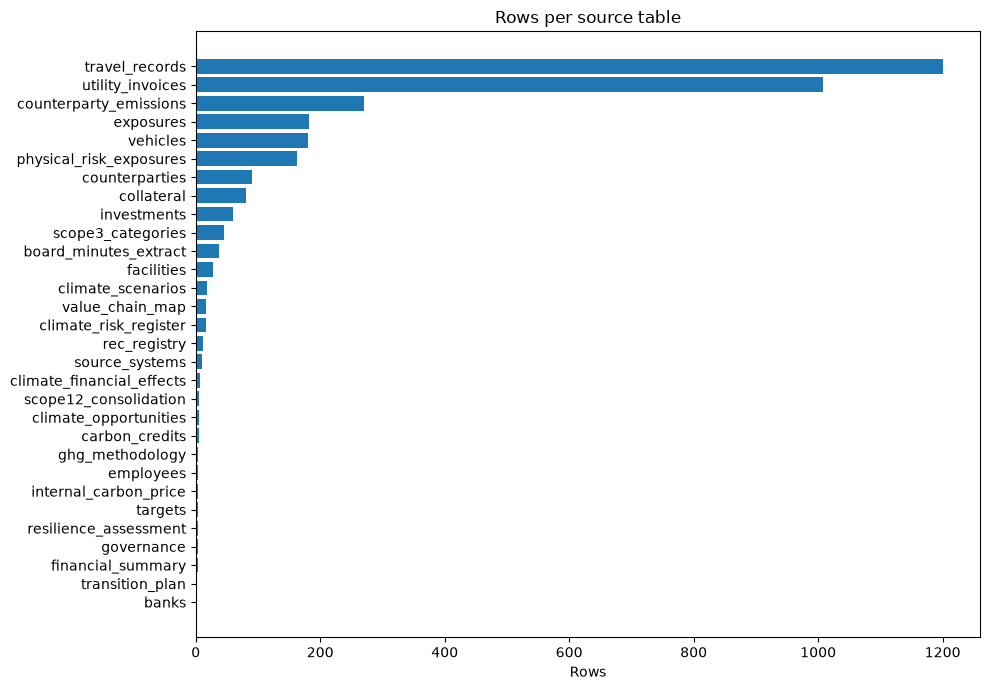

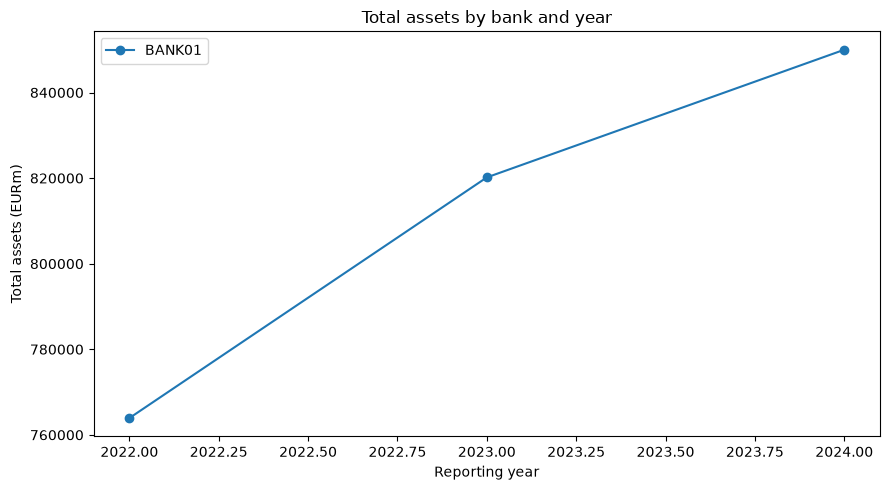

In [2]:
# ============================================================
# 1. Load input tables
# ============================================================

def find_csv_files(data_dir: Path) -> list[Path]:
    """
    Load CSV files from the selected folder.
    If the folder only contains nested extracted data, look one level deeper.
    Internal files such as patch_audit_log.csv are ignored.
    """
    ignore_names = {
        "patch_audit_log.csv",
        "patch_summary.csv",
        "requirements_payload_gap_audit.csv",
    }

    files = sorted([
        p for p in data_dir.glob("*.csv")
        if p.name not in ignore_names and not p.name.startswith("patch_")
    ])

    if files:
        return files

    # fallback for zip extractions like data/data/*.csv
    nested_files = sorted([
        p for p in data_dir.rglob("*.csv")
        if p.name not in ignore_names and not p.name.startswith("patch_")
    ])

    return nested_files

# Optional fallback: extract data.zip only if neither raw nor patched CSVs are ready.
if not folder_has_base_csvs(DATA_DIR) and ZIP_PATH.exists():
    print(f"Base CSVs were not found in {DATA_DIR}. Extracting fallback zip: {ZIP_PATH}")
    zip_extract_dir = DATA_DIR.parent / "_zip_extracted"
    zip_extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(zip_extract_dir)

    # Find the extracted folder that contains banks.csv
    possible_dirs = [zip_extract_dir, *zip_extract_dir.rglob("*")]
    for candidate in possible_dirs:
        if candidate.is_dir() and (candidate / "banks.csv").exists():
            DATA_DIR = candidate
            DATA_SOURCE = "extracted data.zip"
            break

csv_files = find_csv_files(DATA_DIR)

if not csv_files:
    raise FileNotFoundError(
        f"No usable source CSV files found in {DATA_DIR}.\n"
        "Expected files such as banks.csv, financial_summary.csv, targets.csv.\n"
        "Do not point DATA_DIR to a folder that only contains patch_audit_log.csv."
    )

tables = {
    p.stem: pd.read_csv(p)
    for p in csv_files
}

missing_required_tables = [
    table_name for table_name in REQUIRED_BASE_TABLES
    if table_name not in tables
]

if missing_required_tables:
    available = ", ".join(sorted(tables.keys()))
    missing = ", ".join(missing_required_tables)
    raise KeyError(
        "Required source tables are missing.\n"
        f"Missing: {missing}\n\n"
        f"DATA_DIR used: {DATA_DIR}\n"
        f"Available tables: {available}\n\n"
        "Most likely cause: the batch canonical folder does not contain all required base CSVs.\n"
        "Fix: upload the full CSV set or complete the mapping/canonical build step before running this notebook."
    )

print(f"Loaded {len(tables)} source tables from {DATA_SOURCE}: {DATA_DIR}")
print("Tables loaded:")
for name in sorted(tables.keys()):
    print("-", name)

inventory = pd.DataFrame([
    {
        "table": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_cells": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
    }
    for name, df in sorted(tables.items())
])

display(inventory)

missing_summary = []
for name, df in sorted(tables.items()):
    for col in df.columns:
        missing_count = int(df[col].isna().sum())
        if missing_count:
            missing_summary.append({
                "table": name,
                "column": col,
                "missing_count": missing_count,
                "missing_pct": round(missing_count / len(df) * 100, 2) if len(df) else 0,
            })

missing_summary = pd.DataFrame(missing_summary).sort_values(
    ["missing_pct", "missing_count"],
    ascending=False,
) if missing_summary else pd.DataFrame(columns=["table", "column", "missing_count", "missing_pct"])

display(missing_summary.head(30))

# Table size overview
inventory_sorted = inventory.sort_values("rows", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(inventory_sorted["table"], inventory_sorted["rows"])
plt.title("Rows per source table")
plt.xlabel("Rows")
plt.tight_layout()
plt.show()

# Financial scale by bank/year
if "financial_summary" in tables:
    fs_viz = tables["financial_summary"].copy()

    plt.figure(figsize=(9, 5))
    for bank_id, group in fs_viz.groupby("bank_id"):
        group = group.sort_values("reporting_year")
        plt.plot(group["reporting_year"], group["total_assets_meur"], marker="o", label=bank_id)

    plt.title("Total assets by bank and year")
    plt.xlabel("Reporting year")
    plt.ylabel("Total assets (EURm)")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 2. Load IFRS requirements as a payload-enrichment checklist

This is **not** report-generation evidence mapping.

The purpose is only to answer this question:

> If IFRS requirements ask for a disclosure theme, and the CSV data contains useful fields for that theme, is that data present in the payload structure?

The notebook uses the requirements to create a deterministic enrichment checklist, then adds the missing source data or summaries to the payloads.


In [3]:

# ============================================================
# 2. Requirement loading and deterministic enrichment checklist
# ============================================================

def load_requirement_file(section_key: str, path: Path) -> list[dict]:
    if not path.exists():
        return []

    with open(path, "r", encoding="utf-8") as f:
        obj = json.load(f)

    records = []
    for standard_name, standard_payload in obj.get("standards", {}).items():
        for req in standard_payload.get("requirements", []):
            row = dict(req)
            row["section_key"] = section_key
            row["standard_group"] = standard_name
            records.append(row)
    return records

requirement_records = []
for section_key, requirement_path in REQUIREMENT_FILES.items():
    path = Path(requirement_path)
    rows = load_requirement_file(section_key, path)
    requirement_records.extend(rows)
    print(f"{section_key:24s}: {len(rows):>3} requirements loaded from {path.name if path.exists() else 'MISSING'}")

requirements_df = pd.DataFrame(requirement_records)

if requirements_df.empty:
    print("No requirements loaded. Payload enrichment will still run using the fixed enrichment schema.")
    requirements_by_section = pd.DataFrame(columns=["section_key", "requirement_count"])
else:
    requirements_by_section = (
        requirements_df.groupby("section_key")
        .size()
        .reset_index(name="requirement_count")
        .sort_values("section_key")
    )
    display(requirements_by_section)

# This is a deterministic checklist, not an evidence map.
# Each row says: the requirements ask for this disclosure theme; these source CSV tables
# contain data that supports the theme; these payload fields should exist.
PAYLOAD_ENRICHMENT_CHECKLIST = [
    {
        "theme": "Scope 2 contractual instruments / RECs",
        "sections": ["metrics_and_targets"],
        "requirement_tags": ["scope_2", "ghg_emissions"],
        "requirement_terms": ["contractual instruments", "Scope 2"],
        "source_tables": ["rec_registry", "utility_invoices"],
        "payload_fields_to_add": ["rec_registry", "energy_consumption_summary"],
    },
    {
        "theme": "GHG measurement approach, inputs and assumptions",
        "sections": ["metrics_and_targets"],
        "requirement_tags": ["ghg_emissions"],
        "requirement_terms": ["measurement approach", "inputs", "assumptions", "greenhouse gas emissions"],
        "source_tables": ["ghg_methodology", "utility_invoices", "vehicles", "travel_records"],
        "payload_fields_to_add": ["ghg_methodology", "energy_consumption_summary"],
    },
    {
        "theme": "Financed emissions by asset class, sector and data quality",
        "sections": ["metrics_and_targets"],
        "requirement_tags": ["scope_3", "ghg_emissions"],
        "requirement_terms": ["financed emissions", "Category 15", "commercial banking"],
        "source_tables": ["exposures", "counterparties", "counterparty_emissions"],
        "payload_fields_to_add": ["financed_emissions_loans_detail", "financed_emissions_by_asset_class", "financed_emissions_by_sector"],
    },
    {
        "theme": "Transition risk exposure amounts and percentages",
        "sections": ["strategy", "risk_management", "metrics_and_targets"],
        "requirement_tags": ["metrics", "business_model_value_chain"],
        "requirement_terms": ["transition risks", "amount and percentage", "assets", "business activities"],
        "source_tables": ["exposures", "counterparties", "climate_risk_register"],
        "payload_fields_to_add": ["portfolio_composition", "counterparty_transition_summary"],
    },
    {
        "theme": "Physical risk exposure amounts and asset concentration",
        "sections": ["strategy", "risk_management", "metrics_and_targets"],
        "requirement_tags": ["business_model_value_chain"],
        "requirement_terms": ["physical risks", "geographical areas", "facilities", "types of assets"],
        "source_tables": ["physical_risk_exposures", "collateral", "facilities"],
        "payload_fields_to_add": ["physical_risk_exposures", "collateral_risk_summary", "facilities", "facilities_summary"],
    },
    {
        "theme": "Business model and value chain concentration",
        "sections": ["strategy"],
        "requirement_tags": ["business_model_value_chain"],
        "requirement_terms": ["business model", "value chain", "where", "concentrated"],
        "source_tables": ["value_chain_map", "exposures", "facilities", "collateral"],
        "payload_fields_to_add": ["value_chain_map", "portfolio_composition", "facilities_summary", "collateral_risk_summary"],
    },
    {
        "theme": "Governance skills, training, remuneration and management oversight",
        "sections": ["governance"],
        "requirement_tags": ["governance_body", "management_role", "remuneration", "targets"],
        "requirement_terms": ["skills", "competencies", "remuneration", "management", "targets"],
        "source_tables": ["governance", "employees", "board_minutes_extract", "targets"],
        "payload_fields_to_add": ["employees", "targets"],
    },
    {
        "theme": "Financial effects and material adjustment flags",
        "sections": ["strategy", "general_requirements"],
        "requirement_tags": ["financial_effects", "materiality"],
        "requirement_terms": ["financial effects", "material adjustment", "financial position", "cash flows"],
        "source_tables": ["climate_financial_effects", "financial_summary"],
        "payload_fields_to_add": ["climate_financial_effects"],
    },
    {
        "theme": "Source systems and connected information",
        "sections": ["general_requirements", "risk_management"],
        "requirement_tags": ["connected_information", "source_guidance"],
        "requirement_terms": ["data", "assumptions", "sources of guidance", "financial statements"],
        "source_tables": ["source_systems", "financial_summary"],
        "payload_fields_to_add": ["source_systems"],
    },
]

def requirement_count_for_check(check: dict) -> int:
    if requirements_df.empty:
        return 0

    tags = set(check.get("requirement_tags", []))
    terms = [str(t).lower() for t in check.get("requirement_terms", [])]
    section_filter = set(check.get("sections", []))

    matches = []
    for _, req in requirements_df.iterrows():
        section_match = not section_filter or req.get("section_key") in section_filter
        req_tags = set(req.get("evidence_tags", []) or [])
        text = str(req.get("requirement_text", "")).lower()
        tag_match = bool(tags.intersection(req_tags)) if tags else False
        term_match = any(term in text for term in terms) if terms else False
        if section_match and (tag_match or term_match):
            matches.append(req.get("requirement_id"))
    return len(set(matches))

audit_rows = []
for check in PAYLOAD_ENRICHMENT_CHECKLIST:
    source_tables = check["source_tables"]
    audit_rows.append({
        "theme": check["theme"],
        "matching_requirement_count": requirement_count_for_check(check),
        "source_tables": ", ".join(source_tables),
        "source_tables_available": all(name in tables for name in source_tables),
        "payload_fields_to_add": ", ".join(check["payload_fields_to_add"]),
    })

requirements_enrichment_overview = pd.DataFrame(audit_rows)
display(requirements_enrichment_overview)


general_requirements    : 108 requirements loaded from general_requirements_requirements.json
governance              :  15 requirements loaded from governance_requirements.json
strategy                :  70 requirements loaded from strategy_requirements.json
risk_management         :  17 requirements loaded from risk_management_requirements.json
metrics_targets         : 151 requirements loaded from metrics_and_targets_requirements.json


,section_key,requirement_count
0,general_requirements,108
1,governance,15
2,metrics_targets,151
3,risk_management,17
4,strategy,70


,theme,matching_requirement_count,source_tables,source_tables_available,payload_fields_to_add
0,Scope 2 contractual instruments / RECs,0,"rec_registry, utility_invoices",True,"rec_registry, energy_consumption_summary"
1,"GHG measurement approach, inputs and assumptions",0,"ghg_methodology, utility_invoices, vehicles, t...",True,"ghg_methodology, energy_consumption_summary"
2,"Financed emissions by asset class, sector and ...",0,"exposures, counterparties, counterparty_emissions",True,"financed_emissions_loans_detail, financed_emis..."
3,Transition risk exposure amounts and percentages,15,"exposures, counterparties, climate_risk_register",True,"portfolio_composition, counterparty_transition..."
4,Physical risk exposure amounts and asset conce...,12,"physical_risk_exposures, collateral, facilities",True,"physical_risk_exposures, collateral_risk_summa..."
5,Business model and value chain concentration,12,"value_chain_map, exposures, facilities, collat...",True,"value_chain_map, portfolio_composition, facili..."
6,"Governance skills, training, remuneration and ...",14,"governance, employees, board_minutes_extract, ...",True,"employees, targets"
7,Financial effects and material adjustment flags,73,"climate_financial_effects, financial_summary",True,climate_financial_effects
8,Source systems and connected information,42,"source_systems, financial_summary",True,source_systems


## 3. Emissions calculations and KPI building

This step calculates operational emissions, financed-emissions metrics, target progress proxies, and KPI summaries.


,target_id,bank_id,target_year,schedule_elapsed_pct_2024,target_progress_pct_2024,progress_basis
0,TGT001,BANK01,2030,40.0,None,schedule_elapsed_only
1,TGT002,BANK01,2030,25.0,None,schedule_elapsed_only
2,TGT003,BANK01,2050,13.3,None,schedule_elapsed_only


,bank_id,reporting_year,scope1_gas_tco2e,scope1_fleet_tco2e,scope1_total_tco2e,fleet_data_available
0,BANK01,2022,2072.3827,0.000000,2072.382700,False
1,BANK01,2023,2032.5260,0.000000,2032.526000,False
2,BANK01,2024,2012.3308,622.577517,2634.908317,True


,bank_id,reporting_year,scope2_location_tco2e,scope2_market_tco2e
0,BANK01,2022,7697.2148,5001.3209
1,BANK01,2023,7314.0062,4014.4341
2,BANK01,2024,6963.4977,3060.5382


,bank_id,reporting_year,scope3_travel_tco2e,travel_data_available
0,BANK01,2024,289.8833,True


,bank_id,financed_em_loans_tco2e,reporting_year,total_loans_meur,carbon_intensity_tco2e_per_meur_lending
0,BANK01,3.655018e+07,2022,31150.64,1173.3363
1,BANK01,3.742759e+07,2023,31150.64,1201.5032
2,BANK01,3.597317e+07,2024,31150.64,1154.8131


,bank_id,scope1_2024_tco2e,scope2_location_2024_tco2e,scope2_market_2024_tco2e,scope3_travel_2024_tco2e,financed_emissions_2024_tco2e,carbon_intensity_2024_tco2e_per_meur
0,BANK01,2634.908317,6963.4977,3060.5382,289.8833,3.597317e+07,1154.8131


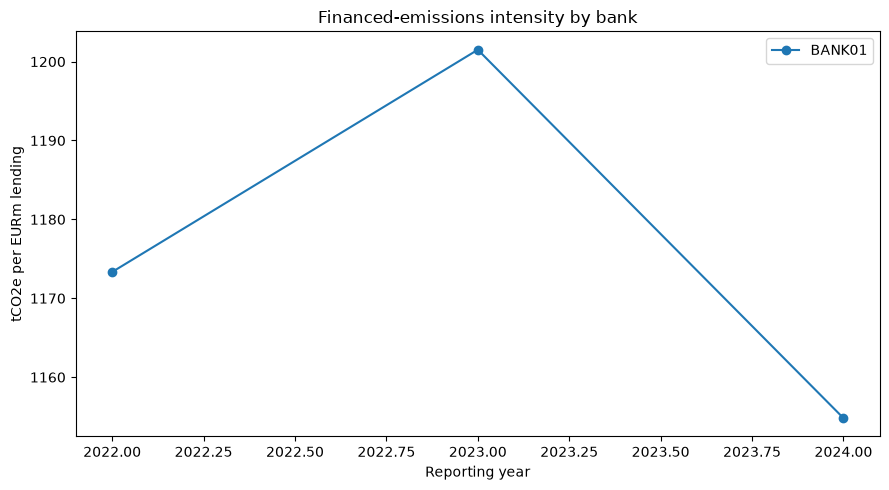

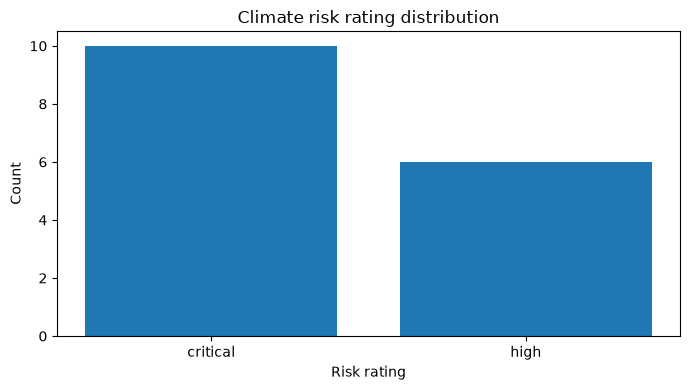

In [4]:

# ============================================================
# 2. Shared helpers
# ============================================================

def safe_float(value):
    try:
        value = float(value)
        return value if value == value else None
    except Exception:
        return None

def clean_for_json(value):
    if isinstance(value, dict):
        return {k: clean_for_json(v) for k, v in value.items()}

    if isinstance(value, list):
        return [clean_for_json(v) for v in value]

    if hasattr(value, "item") and not isinstance(value, (str, bytes)):
        try:
            value = value.item()
        except Exception:
            pass

    try:
        if pd.isna(value):
            return None
    except Exception:
        pass

    return value

def dump_strict_json(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(clean_for_json(obj), f, indent=2, default=str, allow_nan=False, ensure_ascii=False)

HIGH_CARBON_NACE = {"B06", "B07", "B08", "B09", "C19", "C20", "D35", "H49", "H50", "H51", "C24"}
FOSSIL_FUEL_NACE = {"B06", "B07", "C19", "D35"}

def is_high_carbon_nace(code):
    code = str(code or "").upper()
    return code in HIGH_CARBON_NACE

def is_fossil_fuel_nace(code):
    code = str(code or "").upper()
    return code in FOSSIL_FUEL_NACE

def bank_slice(df, bank_id):
    if df is None or not hasattr(df, "columns") or getattr(df, "empty", False):
        return []
    if "bank_id" not in df.columns:
        return df.to_dict("records")
    return df[df["bank_id"] == bank_id].to_dict("records")

def bank_slice_optional(tables, table_name, bank_id):
    if table_name not in tables:
        return []
    return bank_slice(tables[table_name], bank_id)

def compute_target_progress(row):
    try:
        baseline_year = int(row.get("baseline_year", 2019))
        target_year = int(row.get("target_year", 2030))
    except Exception:
        baseline_year, target_year = None, None

    schedule = None
    if baseline_year is not None and target_year is not None and target_year > baseline_year:
        schedule = round(min((REPORTING_YEAR - baseline_year) / (target_year - baseline_year) * 100, 100.0), 1)

    actual = None  # do not fabricate achieved progress
    if actual is not None:
        basis = "actual_vs_baseline"
    elif schedule is not None:
        basis = "schedule_elapsed_only"
    else:
        basis = "unavailable"

    return {
        "schedule_elapsed_pct_2024": schedule,
        "actual_progress_pct_2024": actual,
        "progress_basis": basis,
        "progress_is_schedule_proxy": actual is None and schedule is not None,
    }


# ============================================================
# 3. Target preparation
# ============================================================

targets = tables["targets"].copy()

if "interim_milestones_json" in targets.columns:
    targets["milestones_parsed"] = targets["interim_milestones_json"].apply(
        lambda x: json.loads(x) if pd.notna(x) and str(x).strip() else []
    )
else:
    targets["milestones_parsed"] = [[] for _ in range(len(targets))]

progress = targets.apply(compute_target_progress, axis=1, result_type="expand")
for col in ["schedule_elapsed_pct_2024", "actual_progress_pct_2024", "progress_basis", "progress_is_schedule_proxy"]:
    targets[col] = progress[col]

targets["target_progress_pct_2024"] = targets["actual_progress_pct_2024"]

display(targets[["target_id", "bank_id", "target_year", "schedule_elapsed_pct_2024", "target_progress_pct_2024", "progress_basis"]].head())


# ============================================================
# 4. Scope 1, 2 and Scope 3 travel
# ============================================================

travel = tables["travel_records"].copy()
travel["travel_date"] = pd.to_datetime(travel["travel_date"])
travel["reporting_year"] = travel["travel_date"].dt.year

util = tables["utility_invoices"].copy()
util["invoice_month"] = pd.to_datetime(util["invoice_month"])

scope1_gas = (
    util.groupby(["bank_id", "invoice_year"])["scope1_gas_tco2e"]
    .sum()
    .reset_index()
    .rename(columns={"invoice_year": "reporting_year"})
)

vehicles = tables["vehicles"].copy()
if "scope1_tco2e_2024_clean" not in vehicles.columns:
    def recalc_fleet_scope1(row):
        fuel_type = str(row.get("fuel_type", "")).lower()
        fuel_litres = safe_float(row.get("annual_fuel_consumption_l")) or 0.0
        if fuel_type == "electric" or fuel_litres <= 0:
            return 0.0
        return round(fuel_litres * FLEET_EMISSION_FACTOR_KGCO2_PER_LITRE / 1000, 6)
    vehicles["scope1_tco2e_2024_clean"] = vehicles.apply(recalc_fleet_scope1, axis=1)

scope1_fleet = (
    vehicles.groupby("bank_id")["scope1_tco2e_2024_clean"]
    .sum()
    .reset_index()
    .rename(columns={"scope1_tco2e_2024_clean": "scope1_fleet_tco2e"})
)
scope1_fleet["reporting_year"] = REPORTING_YEAR

scope1 = scope1_gas.merge(scope1_fleet, on=["bank_id", "reporting_year"], how="left").fillna(0)
scope1["scope1_total_tco2e"] = scope1["scope1_gas_tco2e"] + scope1["scope1_fleet_tco2e"]
scope1["fleet_data_available"] = scope1["reporting_year"] == REPORTING_YEAR

scope2 = (
    util.groupby(["bank_id", "invoice_year"])
    .agg(scope2_location_tco2e=("scope2_location_tco2e", "sum"), scope2_market_tco2e=("scope2_market_tco2e", "sum"))
    .reset_index()
    .rename(columns={"invoice_year": "reporting_year"})
)

scope2_check = scope2[scope2["reporting_year"] == REPORTING_YEAR]
if not (scope2_check["scope2_market_tco2e"] <= scope2_check["scope2_location_tco2e"]).all():
    print("WARNING: Some Scope 2 market-based values exceed location-based values. Check REC treatment.")

scope3_travel = (
    travel.groupby(["bank_id", "reporting_year"])["emissions_kg_co2e"]
    .sum()
    .div(1000)
    .reset_index()
    .rename(columns={"emissions_kg_co2e": "scope3_travel_tco2e"})
)
scope3_travel["travel_data_available"] = True

display(scope1.head())
display(scope2.head())
display(scope3_travel.head())


# ============================================================
# 5. PCAF-style financed emissions for loans
# ============================================================

exp = tables["exposures"].copy()
cp = tables["counterparties"].copy()
cp_em = tables["counterparty_emissions"].copy()

cp_em_enriched = cp_em.merge(
    cp[["counterparty_id", "evic_meur", "ppp_adjusted_gdp_meur", "national_scope1_tco2e", "nace_code"]],
    on="counterparty_id",
    how="left",
)

financed_by_year_records = []
loan_emissions_records = []

for year in sorted(cp_em_enriched["reporting_year"].dropna().unique()):
    cp_em_year = cp_em_enriched[cp_em_enriched["reporting_year"] == year].copy()

    cols = ["counterparty_id", "total_ghg_tco2e", "evic_meur", "ppp_adjusted_gdp_meur", "national_scope1_tco2e", "nace_code"]
    optional_cols = [c for c in ["pcaf_data_quality_score", "data_source"] if c in cp_em_year.columns]
    exp_em_year = exp.merge(cp_em_year[cols + optional_cols], on="counterparty_id", how="left")

    corporate_mask = exp_em_year["nace_code"].astype(str).str.upper() != "O84"
    sovereign_mask = exp_em_year["nace_code"].astype(str).str.upper() == "O84"

    exp_em_year["attributed_emissions_tco2e"] = np.nan
    exp_em_year.loc[corporate_mask, "attributed_emissions_tco2e"] = (
        exp_em_year.loc[corporate_mask, "outstanding_amount_meur"] / exp_em_year.loc[corporate_mask, "evic_meur"]
    ) * exp_em_year.loc[corporate_mask, "total_ghg_tco2e"]

    exp_em_year.loc[sovereign_mask, "attributed_emissions_tco2e"] = (
        exp_em_year.loc[sovereign_mask, "outstanding_amount_meur"] / exp_em_year.loc[sovereign_mask, "ppp_adjusted_gdp_meur"]
    ) * exp_em_year.loc[sovereign_mask, "national_scope1_tco2e"]

    exp_em_year["reporting_year"] = int(year)
    loan_emissions_records.append(exp_em_year)

    totals = (
        exp_em_year.groupby("bank_id")["attributed_emissions_tco2e"]
        .sum()
        .reset_index()
        .rename(columns={"attributed_emissions_tco2e": "financed_em_loans_tco2e"})
    )
    totals["reporting_year"] = int(year)
    financed_by_year_records.append(totals)

loan_emissions_detail = pd.concat(loan_emissions_records, ignore_index=True)
financed_by_year = pd.concat(financed_by_year_records, ignore_index=True)

loan_denominators = tables["banks"][["bank_id", "total_loans_meur"]].copy()

financed_by_year = financed_by_year.merge(loan_denominators, on="bank_id", how="left")
financed_by_year["carbon_intensity_tco2e_per_meur_lending"] = (
    financed_by_year["financed_em_loans_tco2e"] / financed_by_year["total_loans_meur"]
).round(4)

display(financed_by_year.head())


# ============================================================
# 6. Investment emissions
# ============================================================

inv = tables["investments"].copy()
inv = inv[inv["reporting_year"] == REPORTING_YEAR].copy()

listed_equity = inv[inv["asset_class"] == "listed_equity"].copy()
sovereign_bonds = inv[inv["asset_class"] == "sovereign_bond"].copy()

listed_equity["attribution_factor"] = listed_equity["market_value_meur"] / listed_equity["issuer_evic_meur"]
listed_equity["attributed_emissions_proxy_tco2e"] = listed_equity["attribution_factor"] * listed_equity["issuer_revenue_meur"]
listed_equity["attributed_emissions_tco2e"] = listed_equity["attributed_emissions_proxy_tco2e"]
listed_equity["emissions_proxy_used"] = True
listed_equity["proxy_basis"] = "issuer_revenue_meur"
listed_equity["proxy_confidence"] = "low"
listed_equity["proxy_reason"] = "Direct issuer emissions unavailable. Revenue used as PCAF B61 proxy. Do not treat as verified emissions."

sovereign_reference = cp[cp["nace_code"].astype(str).str.upper() == "O84"][["country", "national_scope1_tco2e", "ppp_adjusted_gdp_meur"]].drop_duplicates()
sovereign_bonds = sovereign_bonds.merge(sovereign_reference, on="country", how="left")
sovereign_bonds["attribution_factor"] = sovereign_bonds["nominal_amount_meur"] / sovereign_bonds["ppp_gdp_meur"]
sovereign_bonds["attributed_emissions_tco2e"] = sovereign_bonds["attribution_factor"] * sovereign_bonds["national_scope1_tco2e"]
sovereign_bonds["pcaf_method"] = "PCAF B62A sovereign bonds"
sovereign_bonds["emissions_proxy_used"] = False


# ============================================================
# 7. Financial summary update and KPIs
# ============================================================

fs = tables["financial_summary"].copy()
fs = fs.drop(columns=[col for col in ["financed_em_loans_tco2e", "carbon_intensity_tco2e_per_meur_lending"] if col in fs.columns])
fs = fs.merge(
    financed_by_year[["bank_id", "reporting_year", "financed_em_loans_tco2e", "carbon_intensity_tco2e_per_meur_lending"]],
    on=["bank_id", "reporting_year"],
    how="left",
)
tables["financial_summary"] = fs

def build_sector_kpis():
    merged = exp.merge(cp[["counterparty_id", "nace_code"]], on="counterparty_id", how="left")
    sector_kpis = {}
    for bank_id, group in merged.groupby("bank_id"):
        total = group["outstanding_amount_meur"].sum()
        high = group[group["nace_code"].apply(is_high_carbon_nace)]["outstanding_amount_meur"].sum()
        fossil = group[group["nace_code"].apply(is_fossil_fuel_nace)]["outstanding_amount_meur"].sum()
        sector_kpis[bank_id] = {
            "high_carbon_sector_exposure_pct": round(high / total * 100, 2) if total else None,
            "fossil_fuel_exposure_pct": round(fossil / total * 100, 2) if total else None,
            "high_carbon_sector_exposure_meur": round(high, 2),
            "fossil_fuel_exposure_meur": round(fossil, 2),
        }
    return sector_kpis

sector_kpis = build_sector_kpis()

def build_data_quality_summary(bank_id):
    bank_exp = exp.merge(cp[["counterparty_id", "data_source_type"]], on="counterparty_id", how="left")
    bank_exp = bank_exp[bank_exp["bank_id"] == bank_id].copy()
    total = bank_exp["outstanding_amount_meur"].sum()
    if total == 0:
        return {}
    return (
        bank_exp.groupby("data_source_type")["outstanding_amount_meur"]
        .sum()
        .div(total)
        .mul(100)
        .round(1)
        .to_dict()
    )

def build_carbon_credit_summary(bank_id):
    if "carbon_credits" not in tables:
        return None
    credits = tables["carbon_credits"]
    bank_credits = credits[(credits["bank_id"] == bank_id) & (credits["reporting_year"] == REPORTING_YEAR)].copy()
    if bank_credits.empty:
        return None
    total = bank_credits["tonnes_co2e"].sum()
    retired = bank_credits[bank_credits["use"] == "retirement_against_emissions"] if "use" in bank_credits.columns else bank_credits
    removal = bank_credits[bank_credits["credit_type"] == "carbon_removal"] if "credit_type" in bank_credits.columns else bank_credits.iloc[0:0]
    high_perm = bank_credits[bank_credits["permanence_rating"] == "high"] if "permanence_rating" in bank_credits.columns else bank_credits.iloc[0:0]
    add_verified = bank_credits[bank_credits["additionality_verified"] == True] if "additionality_verified" in bank_credits.columns else bank_credits.iloc[0:0]
    return {
        "total_credits_tco2e": int(total),
        "retired_tco2e": int(retired["tonnes_co2e"].sum()) if not retired.empty else 0,
        "removal_pct": round(removal["tonnes_co2e"].sum() / total * 100, 1) if total else 0,
        "high_permanence_pct": round(high_perm["tonnes_co2e"].sum() / total * 100, 1) if total else 0,
        "additionality_verified_pct": round(add_verified["tonnes_co2e"].sum() / total * 100, 1) if total else 0,
    }

def build_reporting_kpis(bank_id):
    def get_2024_value(df, year_col, value_col):
        rows = df[(df["bank_id"] == bank_id) & (df[year_col] == REPORTING_YEAR)]
        if rows.empty:
            return None
        return rows.iloc[0][value_col]

    def fs_val(col):
        rows = fs[(fs["bank_id"] == bank_id) & (fs["reporting_year"] == REPORTING_YEAR)]
        if rows.empty or col not in rows.columns:
            return None
        return rows.iloc[0][col]

    gov_rows = tables["governance"][
        (tables["governance"]["bank_id"] == bank_id) &
        (tables["governance"]["reporting_year"] == REPORTING_YEAR)
    ]
    gov_row = gov_rows.iloc[0].to_dict() if not gov_rows.empty else {}
    targets_bank = targets[targets["bank_id"] == bank_id].copy()

    target_cols = [
        "target_id", "target_type", "scope_coverage", "status", "target_year", "target_framework",
        "target_progress_pct_2024", "schedule_elapsed_pct_2024", "progress_basis", "progress_is_schedule_proxy"
    ]
    target_cols = [c for c in target_cols if c in targets_bank.columns]

    return clean_for_json({
        "scope1_2024_tco2e": get_2024_value(scope1, "reporting_year", "scope1_total_tco2e"),
        "scope2_location_2024_tco2e": get_2024_value(scope2, "reporting_year", "scope2_location_tco2e"),
        "scope2_market_2024_tco2e": get_2024_value(scope2, "reporting_year", "scope2_market_tco2e"),
        "scope3_travel_2024_tco2e": get_2024_value(scope3_travel, "reporting_year", "scope3_travel_tco2e"),
        "financed_emissions_2024_tco2e": fs_val("financed_em_loans_tco2e"),
        "carbon_intensity_2024_tco2e_per_meur": fs_val("carbon_intensity_tco2e_per_meur_lending"),
        "green_loans_pct_2024": fs_val("green_loans_pct"),
        "climate_capex_2024_meur": fs_val("climate_capex_meur"),
        "climate_opex_2024_meur": fs_val("climate_opex_meur"),
        "total_assets_2024_meur": fs_val("total_assets_meur"),
        "total_loans_2024_meur": fs_val("total_loans_meur"),
        "governance_maturity": {
            "esg_committee_exists": gov_row.get("esg_committee_exists"),
            "esg_committee_meetings": gov_row.get("esg_committee_meetings_per_year"),
            "board_climate_expertise_pct": gov_row.get("board_climate_expertise_pct"),
            "ceo_esg_compensation_pct": gov_row.get("ceo_esg_compensation_pct"),
            "external_assurance": gov_row.get("external_assurance"),
            "erm_integration": bool(gov_row.get("erm_integration_flag")) if gov_row.get("erm_integration_flag") is not None else None,
        },
        "target_summary": targets_bank[target_cols].rename(columns={"target_type": "type", "target_framework": "framework", "scope_coverage": "scope"}).to_dict("records") if target_cols else [],
        **sector_kpis.get(bank_id, {}),
        "emissions_data_quality_summary": build_data_quality_summary(bank_id),
        "carbon_credit_summary": build_carbon_credit_summary(bank_id),
        "scope1_fleet_included": True,
        "scope3_travel_comparative_available": False,
        "listed_equity_emissions_are_proxy": True,
    })

kpi_preview = pd.DataFrame([{"bank_id": bank_id, **build_reporting_kpis(bank_id)} for bank_id in tables["banks"]["bank_id"].unique()])
display(kpi_preview[["bank_id", "scope1_2024_tco2e", "scope2_location_2024_tco2e", "scope2_market_2024_tco2e", "scope3_travel_2024_tco2e", "financed_emissions_2024_tco2e", "carbon_intensity_2024_tco2e_per_meur"]])

# Visualisations from calculated metrics.
plt.figure(figsize=(9, 5))
for bank_id, group in fs.groupby("bank_id"):
    group = group.sort_values("reporting_year")
    plt.plot(group["reporting_year"], group["carbon_intensity_tco2e_per_meur_lending"], marker="o", label=bank_id)
plt.title("Financed-emissions intensity by bank")
plt.xlabel("Reporting year")
plt.ylabel("tCO2e per EURm lending")
plt.legend()
plt.tight_layout()
plt.show()

if "climate_risk_register" in tables:
    risk_counts = tables["climate_risk_register"]["risk_rating"].value_counts().sort_index()
    plt.figure(figsize=(7, 4))
    plt.bar(risk_counts.index, risk_counts.values)
    plt.title("Climate risk rating distribution")
    plt.xlabel("Risk rating")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


## 4. Requirements-informed payload enrichment and payload generation

This step adds useful data already present in the CSVs but missing from the initial payload structure.

Examples:
- REC registry records for Scope 2 contractual instruments.
- Energy consumption summaries for GHG input/assumption support.
- Portfolio composition and transition-risk summaries for transition-risk exposure requirements.
- Collateral and facilities summaries for physical-risk concentration requirements.
- Financed-emissions loan detail and aggregation for commercial banking Scope 3 Category 15 requirements.
- Employees/training/remuneration-related data for governance skills and remuneration requirements.


In [5]:

# ============================================================
# 8. Build full and section-specific payloads with requirements-informed enrichment
# ============================================================

SECTION_KEYS = {
    "general_requirements": [
        "metadata", "bank", "financial_summary", "general_requirements_context",
        "source_systems", "targets", "scope1", "scope2", "scope3_travel",
        "financed_emissions", "climate_financial_effects",
    ],
    "governance": [
        "metadata", "bank", "governance", "board_minutes", "employees", "targets",
        "climate_risk_register", "reporting_kpis",
    ],
    "strategy": [
        "metadata", "bank", "financial_summary", "climate_scenarios",
        "climate_risk_register", "value_chain_map", "climate_opportunities",
        "targets", "transition_plan", "resilience_assessment",
        "climate_financial_effects", "portfolio_composition",
        "counterparty_transition_summary", "facilities", "facilities_summary",
        "collateral_risk_summary", "reporting_kpis",
    ],
    "risk_management": [
        "metadata", "bank", "source_systems", "climate_risk_register",
        "physical_risk_exposures", "collateral", "collateral_risk_summary",
        "counterparties", "counterparty_transition_summary", "portfolio_composition",
        "value_chain_map", "governance", "climate_financial_effects",
        "reporting_kpis",
    ],
    "metrics_targets": [
        "metadata", "bank", "financial_summary", "scope1", "scope2",
        "scope3_travel", "scope3_categories", "financed_emissions",
        "financed_emissions_loans_detail", "financed_emissions_by_asset_class",
        "financed_emissions_by_sector", "financed_emissions_equity",
        "financed_emissions_sovereign", "targets", "carbon_credits",
        "internal_carbon_price", "rec_registry", "energy_consumption_summary",
        "ghg_methodology", "scope12_consolidation", "employees", "reporting_kpis",
    ],
}

SOURCE_SYSTEMS_BY_TABLE = {
    "banks": "ESG_DATA",
    "financial_summary": "FINANCE",
    "governance": "ERM_GRC",
    "board_minutes_extract": "ERM_GRC",
    "climate_risk_register": "ERM_GRC",
    "climate_scenarios": "ERM_GRC",
    "physical_risk_exposures": "ERM_GRC",
    "climate_financial_effects": "FINANCE",
    "counterparties": "CIF",
    "counterparty_emissions": "ESG_DATA",
    "exposures": "LMS",
    "investments": "TREASURY",
    "utility_invoices": "FACILITIES",
    "rec_registry": "FACILITIES",
    "vehicles": "FLEET",
    "travel_records": "TRAVEL",
    "employees": "HR",
    "targets": "ESG_DATA",
}

def list_available_source_systems(bank_id=None):
    if "source_systems" not in tables:
        return []
    return tables["source_systems"].to_dict("records")

def build_metadata(bank_id):
    investment_rows = tables.get("investments", pd.DataFrame())
    if not investment_rows.empty and "bank_id" in investment_rows.columns:
        bank_investments = investment_rows[investment_rows["bank_id"] == bank_id]
        investment_count = int(len(bank_investments))
        missing_counterparty_count = int(bank_investments["counterparty_id"].isna().sum()) if "counterparty_id" in bank_investments.columns else investment_count
    else:
        investment_count = 0
        missing_counterparty_count = 0

    if investment_count and missing_counterparty_count == investment_count:
        investments_counterparty_note = (
            f"counterparty_id is null across all {investment_count} investment rows. "
            "Investment attribution is maintained at bank level."
        )
    elif investment_count:
        investments_counterparty_note = (
            f"counterparty_id is missing in {missing_counterparty_count} of {investment_count} investment rows. "
            "Issuer-level investment claims are limited to records with counterparty attribution."
        )
    else:
        investments_counterparty_note = "Investment attribution is maintained at bank level."

    return {
        "bank_id": bank_id,
        "reporting_year": REPORTING_YEAR,
        "comparative_years": COMPARATIVE_YEARS,
        "pcaf_methodology": {
            "corporate_loans": "outstanding_amount_meur / evic_meur * total_ghg_tco2e (PCAF Standard §B62)",
            "sovereign_bonds_investments": "nominal_amount_meur / ppp_gdp_meur * national_scope1_tco2e (PCAF Standard §B62A)",
            "listed_equity": "market_value_meur / issuer_evic_meur * issuer_revenue_meur (PCAF Standard §B61 proxy — revenue substituted for direct issuer emissions due to absence of counterparty-level emission data in investment records)",
            "sovereign_bonds_note": "issuer_evic_meur and issuer_revenue_meur are null for sovereign bonds by design. EVIC and revenue are corporate concepts not applicable to sovereigns.",
            "investments_counterparty_note": investments_counterparty_note,
        },
        "scope2_rec_reconciliation": "scope2_market_tco2e is sourced directly from utility_invoices.scope2_market_tco2e, which already reflects market-based accounting with grid emission factors adjusted for renewable energy certificates and PPAs. The rec_registry.csv data is not subtracted again during preparation — it is used for disclosure narrative only (certificate type, volume, registry). There is no double-counting.",
        "risk_rating_methodology": "climate_risk_register.risk_rating is derived from a 5x5 risk matrix: scores 1-2 = low, 3-6 = medium, 8-12 = high, 15-25 = critical. Specifically: likelihood_score * severity_score; critical >= 15, high >= 8, medium >= 3, low < 3. This formula must be used verbatim if the rating methodology is described in the report.",
        "vehicles_correction": {
            "method": "Scope 1 fleet recalculated from annual_fuel_consumption_l * 2.67 kg_CO2/litre / 1000",
            "reason": "Pre-computed scope1_tco2e_2024 had errors including non-zero values for electric vehicles.",
            "electric_vehicles_zeroed": True,
            "emission_factor_source": "Empirically derived — consistent 2.67 kg CO2/litre across all fuel types",
        },
    }


def build_general_requirements_context(bank_id, metadata):
    bank_row = tables["banks"][tables["banks"]["bank_id"] == bank_id].to_dict("records")[0]
    gov_2024 = tables["governance"][(tables["governance"]["bank_id"] == bank_id) & (tables["governance"]["reporting_year"] == REPORTING_YEAR)]
    gov_row = gov_2024.to_dict("records")[0] if not gov_2024.empty else {}

    return {
        "reporting_entity": bank_row.get("bank_name"),
        "bank_id": bank_id,
        "reporting_period_end": bank_row.get("fiscal_year_end"),
        "reporting_year": REPORTING_YEAR,
        "comparative_years": COMPARATIVE_YEARS,
        "reporting_currency": bank_row.get("reporting_currency"),
        "boundary_type": bank_row.get("boundary_type"),
        "regulatory_regime": bank_row.get("regulatory_regime"),
        "standards_basis": "IFRS S1 / IFRS S2-style sustainability-related financial disclosure basis",
        "source_systems": list_available_source_systems(bank_id),
        "pcaf_methodology": metadata["pcaf_methodology"],
        "scope2_rec_reconciliation": metadata["scope2_rec_reconciliation"],
        "risk_rating_methodology": metadata["risk_rating_methodology"],
        "external_assurance": gov_row.get("external_assurance"),
        "assurance_provider": gov_row.get("assurance_provider"),
        "assurance_scope": gov_row.get("assurance_scope"),
        "assurance_standard": gov_row.get("assurance_standard"),
    }

def build_energy_consumption_summary(bank_id):
    if "utility_invoices" not in tables:
        return []
    util_bank = tables["utility_invoices"][tables["utility_invoices"]["bank_id"] == bank_id].copy()
    if util_bank.empty:
        return []
    grouped = (
        util_bank.groupby(["bank_id", "invoice_year"])
        .agg(
            electricity_kwh=("electricity_kwh", "sum"),
            natural_gas_kwh=("natural_gas_kwh", "sum"),
            water_m3=("water_m3", "sum"),
            rec_volume_kwh=("rec_volume_kwh", "sum"),
            electricity_cost_eur=("electricity_cost_eur", "sum"),
            natural_gas_cost_eur=("natural_gas_cost_eur", "sum"),
            scope1_gas_tco2e=("scope1_gas_tco2e", "sum"),
            scope2_location_tco2e=("scope2_location_tco2e", "sum"),
            scope2_market_tco2e=("scope2_market_tco2e", "sum"),
            avg_renewable_share_pct=("renewable_share_pct", "mean"),
            avg_grid_emission_factor_tco2e_per_mwh=("grid_emission_factor_tco2e_per_mwh", "mean"),
        )
        .reset_index()
        .rename(columns={"invoice_year": "reporting_year"})
    )
    grouped["rec_coverage_pct_of_electricity"] = np.where(
        grouped["electricity_kwh"] > 0,
        (grouped["rec_volume_kwh"] / grouped["electricity_kwh"] * 100).round(2),
        None,
    )
    return grouped.to_dict("records")

def build_facilities_summary(bank_id):
    if "facilities" not in tables:
        return []
    fac = tables["facilities"][tables["facilities"]["bank_id"] == bank_id].copy()
    if fac.empty:
        return []
    grouped = (
        fac.groupby(["bank_id", "country", "facility_type", "ownership", "epc_rating"], dropna=False)
        .agg(
            facility_count=("facility_id", "count"),
            total_floor_area_sqm=("floor_area_sqm", "sum"),
            total_headcount=("headcount", "sum"),
        )
        .reset_index()
    )
    return grouped.to_dict("records")

def build_collateral_risk_summary(bank_id):
    if "collateral" not in tables:
        return []
    col = tables["collateral"][tables["collateral"]["bank_id"] == bank_id].copy()
    if col.empty:
        return []
    col["high_physical_risk_flag"] = col["physical_risk_score"].fillna(0) >= 4
    grouped = (
        col.groupby(["bank_id", "country", "property_type", "flood_zone_class", "epc_rating"], dropna=False)
        .agg(
            collateral_count=("collateral_id", "count"),
            exposure_amount_meur=("exposure_amount_meur", "sum"),
            market_value_meur=("market_value_meur", "sum"),
            avg_ltv_pct=("ltv_pct", "mean"),
            avg_physical_risk_score=("physical_risk_score", "mean"),
            high_physical_risk_count=("high_physical_risk_flag", "sum"),
        )
        .reset_index()
    )
    grouped["high_physical_risk_exposure_pct"] = np.where(
        grouped["collateral_count"] > 0,
        (grouped["high_physical_risk_count"] / grouped["collateral_count"] * 100).round(2),
        None,
    )
    return grouped.to_dict("records")

def build_portfolio_composition(bank_id):
    if "exposures" not in tables or "counterparties" not in tables:
        return []
    exp_bank = tables["exposures"][tables["exposures"]["bank_id"] == bank_id].copy()
    if exp_bank.empty:
        return []
    cp_cols = ["counterparty_id", "nace_code", "nace_description", "sector_carbon_tier", "country", "transition_risk_score", "sbti_target_flag", "data_source_type"]
    cp_available = [c for c in cp_cols if c in tables["counterparties"].columns]
    merged = exp_bank.merge(tables["counterparties"][cp_available], on="counterparty_id", how="left")
    merged["high_carbon_sector_flag"] = merged["nace_code"].apply(is_high_carbon_nace)
    merged["fossil_fuel_sector_flag"] = merged["nace_code"].apply(is_fossil_fuel_nace)
    total = merged["outstanding_amount_meur"].sum()
    grouped = (
        merged.groupby(["bank_id", "pcaf_asset_class", "product_type", "sector_carbon_tier", "country"], dropna=False)
        .agg(
            exposure_count=("exposure_id", "count"),
            outstanding_amount_meur=("outstanding_amount_meur", "sum"),
            committed_amount_meur=("committed_amount_meur", "sum"),
            undrawn_amount_meur=("undrawn_amount_meur", "sum"),
            eu_taxonomy_aligned_pct=("eu_taxonomy_aligned", "mean"),
            green_label_pct=("green_label_flag", "mean"),
            avg_transition_risk_score=("transition_risk_score", "mean"),
            high_carbon_exposure_meur=("outstanding_amount_meur", lambda s: merged.loc[s.index][merged.loc[s.index, "high_carbon_sector_flag"]]["outstanding_amount_meur"].sum()),
            fossil_fuel_exposure_meur=("outstanding_amount_meur", lambda s: merged.loc[s.index][merged.loc[s.index, "fossil_fuel_sector_flag"]]["outstanding_amount_meur"].sum()),
        )
        .reset_index()
    )
    grouped["portfolio_pct"] = np.where(total > 0, (grouped["outstanding_amount_meur"] / total * 100).round(4), None)
    grouped["eu_taxonomy_aligned_pct"] = (grouped["eu_taxonomy_aligned_pct"] * 100).round(2)
    grouped["green_label_pct"] = (grouped["green_label_pct"] * 100).round(2)
    return grouped.to_dict("records")

def build_counterparty_transition_summary(bank_id):
    if "counterparties" not in tables:
        return []
    cp_bank = tables["counterparties"][tables["counterparties"]["bank_id"] == bank_id].copy()
    if cp_bank.empty:
        return []
    grouped = (
        cp_bank.groupby(["bank_id", "sector_carbon_tier", "country", "data_source_type"], dropna=False)
        .agg(
            counterparty_count=("counterparty_id", "count"),
            avg_transition_risk_score=("transition_risk_score", "mean"),
            sbti_target_pct=("sbti_target_flag", "mean"),
            listed_counterparty_pct=("is_listed", "mean"),
            sme_pct=("sme_flag", "mean"),
        )
        .reset_index()
    )
    grouped["sbti_target_pct"] = (grouped["sbti_target_pct"] * 100).round(2)
    grouped["listed_counterparty_pct"] = (grouped["listed_counterparty_pct"] * 100).round(2)
    grouped["sme_pct"] = (grouped["sme_pct"] * 100).round(2)
    return grouped.to_dict("records")

def build_financed_emissions_loans_detail(bank_id):
    detail = loan_emissions_detail[
        (loan_emissions_detail["bank_id"] == bank_id) &
        (loan_emissions_detail["reporting_year"] == REPORTING_YEAR)
    ].copy()
    if detail.empty:
        return []
    keep_cols = [
        "exposure_id", "bank_id", "counterparty_id", "product_type", "pcaf_asset_class",
        "outstanding_amount_meur", "committed_amount_meur", "undrawn_amount_meur",
        "nace_code", "total_ghg_tco2e", "attributed_emissions_tco2e",
        "carbon_intensity_tco2e_per_meur_lending", "pcaf_data_quality_score", "data_source", "reporting_year",
    ]
    keep_cols = [c for c in keep_cols if c in detail.columns]
    if "carbon_intensity_tco2e_per_meur_lending" not in detail.columns and "attributed_emissions_tco2e" in detail.columns:
        detail["carbon_intensity_tco2e_per_meur_lending"] = np.where(
            detail["outstanding_amount_meur"] > 0,
            detail["attributed_emissions_tco2e"] / detail["outstanding_amount_meur"],
            None,
        )
        keep_cols.append("carbon_intensity_tco2e_per_meur_lending")
    return detail[keep_cols].to_dict("records")

def build_financed_emissions_by_asset_class(bank_id):
    detail = loan_emissions_detail[
        (loan_emissions_detail["bank_id"] == bank_id) &
        (loan_emissions_detail["reporting_year"] == REPORTING_YEAR)
    ].copy()
    if detail.empty:
        return []
    grouped = (
        detail.groupby(["bank_id", "reporting_year", "pcaf_asset_class"], dropna=False)
        .agg(
            exposure_count=("exposure_id", "count"),
            outstanding_amount_meur=("outstanding_amount_meur", "sum"),
            financed_emissions_tco2e=("attributed_emissions_tco2e", "sum"),
            avg_pcaf_data_quality_score=("pcaf_data_quality_score", "mean"),
        )
        .reset_index()
    )
    grouped["carbon_intensity_tco2e_per_meur"] = np.where(
        grouped["outstanding_amount_meur"] > 0,
        (grouped["financed_emissions_tco2e"] / grouped["outstanding_amount_meur"]).round(4),
        None,
    )
    return grouped.to_dict("records")

def build_financed_emissions_by_sector(bank_id):
    detail = loan_emissions_detail[
        (loan_emissions_detail["bank_id"] == bank_id) &
        (loan_emissions_detail["reporting_year"] == REPORTING_YEAR)
    ].copy()
    if detail.empty:
        return []
    grouped = (
        detail.groupby(["bank_id", "reporting_year", "nace_code"], dropna=False)
        .agg(
            exposure_count=("exposure_id", "count"),
            outstanding_amount_meur=("outstanding_amount_meur", "sum"),
            financed_emissions_tco2e=("attributed_emissions_tco2e", "sum"),
            avg_pcaf_data_quality_score=("pcaf_data_quality_score", "mean"),
        )
        .reset_index()
        .sort_values("financed_emissions_tco2e", ascending=False)
    )
    grouped["carbon_intensity_tco2e_per_meur"] = np.where(
        grouped["outstanding_amount_meur"] > 0,
        (grouped["financed_emissions_tco2e"] / grouped["outstanding_amount_meur"]).round(4),
        None,
    )
    return grouped.to_dict("records")

def build_requirements_payload_gap_audit(bank_id, full_payload):
    payload_fields = set(full_payload.keys())
    rows = []
    for check in PAYLOAD_ENRICHMENT_CHECKLIST:
        source_tables = check["source_tables"]
        fields = check["payload_fields_to_add"]
        rows.append({
            "bank_id": bank_id,
            "theme": check["theme"],
            "matching_requirement_count": requirement_count_for_check(check),
            "source_tables_available": [name for name in source_tables if name in tables],
            "source_tables_missing": [name for name in source_tables if name not in tables],
            "payload_fields_present": [field for field in fields if field in payload_fields],
            "payload_fields_missing_after_enrichment": [field for field in fields if field not in payload_fields],
            "status": "covered_in_payload" if all(field in payload_fields for field in fields) else "source_available_but_payload_field_missing",
        })
    return rows

reporting_payload = {}
requirements_payload_gap_audit = []

for bank_id in tables["banks"]["bank_id"].unique():
    metadata = build_metadata(bank_id)
    general_requirements_context = build_general_requirements_context(bank_id, metadata)

    full_payload = {
        "metadata": metadata,
        "general_requirements_context": general_requirements_context,
        "reporting_kpis": build_reporting_kpis(bank_id),
        "bank": tables["banks"][tables["banks"]["bank_id"] == bank_id].to_dict("records")[0],
        "source_systems": list_available_source_systems(bank_id),
        "financial_summary": bank_slice(fs, bank_id),
        "employees": bank_slice_optional(tables, "employees", bank_id),
        "facilities": bank_slice_optional(tables, "facilities", bank_id),
        "facilities_summary": build_facilities_summary(bank_id),
        "exposures": bank_slice_optional(tables, "exposures", bank_id),
        "counterparties": bank_slice_optional(tables, "counterparties", bank_id),
        "portfolio_composition": build_portfolio_composition(bank_id),
        "counterparty_transition_summary": build_counterparty_transition_summary(bank_id),
        "collateral": bank_slice_optional(tables, "collateral", bank_id),
        "collateral_risk_summary": build_collateral_risk_summary(bank_id),
        "scope1": bank_slice(scope1, bank_id),
        "scope2": bank_slice(scope2, bank_id),
        "scope3_travel": bank_slice(scope3_travel, bank_id),
        "scope3_categories": bank_slice_optional(tables, "scope3_categories", bank_id),
        "financed_emissions": bank_slice(financed_by_year, bank_id),
        "financed_emissions_loans_detail": build_financed_emissions_loans_detail(bank_id),
        "financed_emissions_by_asset_class": build_financed_emissions_by_asset_class(bank_id),
        "financed_emissions_by_sector": build_financed_emissions_by_sector(bank_id),
        "financed_emissions_equity": bank_slice(listed_equity, bank_id),
        "financed_emissions_sovereign": bank_slice(sovereign_bonds, bank_id),
        "targets": bank_slice(targets, bank_id),
        "governance": bank_slice(tables["governance"], bank_id),
        "board_minutes": bank_slice(tables["board_minutes_extract"], bank_id),
        "climate_scenarios": bank_slice(tables["climate_scenarios"], bank_id),
        "climate_risk_register": bank_slice(tables["climate_risk_register"], bank_id),
        "physical_risk_exposures": bank_slice(tables["physical_risk_exposures"], bank_id),
        "carbon_credits": bank_slice_optional(tables, "carbon_credits", bank_id),
        "internal_carbon_price": bank_slice_optional(tables, "internal_carbon_price", bank_id),
        "rec_registry": bank_slice_optional(tables, "rec_registry", bank_id),
        "energy_consumption_summary": build_energy_consumption_summary(bank_id),
        "value_chain_map": bank_slice_optional(tables, "value_chain_map", bank_id),
        "climate_opportunities": bank_slice_optional(tables, "climate_opportunities", bank_id),
        "transition_plan": bank_slice_optional(tables, "transition_plan", bank_id),
        "climate_financial_effects": bank_slice_optional(tables, "climate_financial_effects", bank_id),
        "resilience_assessment": bank_slice_optional(tables, "resilience_assessment", bank_id),
        "ghg_methodology": bank_slice_optional(tables, "ghg_methodology", bank_id),
        "scope12_consolidation": bank_slice_optional(tables, "scope12_consolidation", bank_id),
    }

    full_payload = clean_for_json(full_payload)
    reporting_payload[bank_id] = full_payload
    requirements_payload_gap_audit.extend(build_requirements_payload_gap_audit(bank_id, full_payload))

requirements_payload_gap_audit_df = pd.DataFrame(requirements_payload_gap_audit)
display(requirements_payload_gap_audit_df.head(30))

section_payloads = {}

for bank_id, full_payload in reporting_payload.items():
    section_payloads[bank_id] = {}
    for section_name, keys in SECTION_KEYS.items():
        section_payload = {key: full_payload[key] for key in keys if key in full_payload}
        if "reporting_kpis" not in section_payload:
            section_payload["reporting_kpis"] = full_payload["reporting_kpis"]
        section_payloads[bank_id][section_name] = clean_for_json(section_payload)

print(f"Built {len(reporting_payload)} full payloads and {len(reporting_payload) * len(SECTION_KEYS)} section payloads.")
print("Added requirements-informed payload fields:")
for field in sorted({f for check in PAYLOAD_ENRICHMENT_CHECKLIST for f in check["payload_fields_to_add"]}):
    print(f"  - {field}")


,bank_id,theme,matching_requirement_count,source_tables_available,source_tables_missing,payload_fields_present,payload_fields_missing_after_enrichment,status
0,BANK01,Scope 2 contractual instruments / RECs,0,"[rec_registry, utility_invoices]",[],"[rec_registry, energy_consumption_summary]",[],covered_in_payload
1,BANK01,"GHG measurement approach, inputs and assumptions",0,"[ghg_methodology, utility_invoices, vehicles, ...",[],"[ghg_methodology, energy_consumption_summary]",[],covered_in_payload
2,BANK01,"Financed emissions by asset class, sector and ...",0,"[exposures, counterparties, counterparty_emiss...",[],"[financed_emissions_loans_detail, financed_emi...",[],covered_in_payload
3,BANK01,Transition risk exposure amounts and percentages,15,"[exposures, counterparties, climate_risk_regis...",[],"[portfolio_composition, counterparty_transitio...",[],covered_in_payload
4,BANK01,Physical risk exposure amounts and asset conce...,12,"[physical_risk_exposures, collateral, facilities]",[],"[physical_risk_exposures, collateral_risk_summ...",[],covered_in_payload
5,BANK01,Business model and value chain concentration,12,"[value_chain_map, exposures, facilities, colla...",[],"[value_chain_map, portfolio_composition, facil...",[],covered_in_payload
6,BANK01,"Governance skills, training, remuneration and ...",14,"[governance, employees, board_minutes_extract,...",[],"[employees, targets]",[],covered_in_payload
7,BANK01,Financial effects and material adjustment flags,73,"[climate_financial_effects, financial_summary]",[],[climate_financial_effects],[],covered_in_payload
8,BANK01,Source systems and connected information,42,"[source_systems, financial_summary]",[],[source_systems],[],covered_in_payload


Built 1 full payloads and 5 section payloads.
Added requirements-informed payload fields:
  - climate_financial_effects
  - collateral_risk_summary
  - counterparty_transition_summary
  - employees
  - energy_consumption_summary
  - facilities
  - facilities_summary
  - financed_emissions_by_asset_class
  - financed_emissions_by_sector
  - financed_emissions_loans_detail
  - ghg_methodology
  - physical_risk_exposures
  - portfolio_composition
  - rec_registry
  - source_systems
  - targets
  - value_chain_map


## 5. Export and validation

Exports:
- One full payload per bank.
- One payload per bank per report section.
- One internal requirements/payload gap audit file.


In [6]:
# ============================================================
# 9. Export and validate payload files
# ============================================================

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Clean only generated outputs before exporting.
# This prevents stale files from previous runs, such as payload_BANK01-new.json
# or payload_BANK01_v2.json, from being counted in validation.
for old_file in OUTPUT_DIR.glob("payload_BANK*.json"):
    old_file.unlink()

for old_file_name in [
    "requirements_payload_gap_audit.json",
    "disclosures.csv",
    "data_requirements.csv",
    "disclosure_data_map.csv",
]:
    old_file = OUTPUT_DIR / old_file_name
    if old_file.exists():
        old_file.unlink()

generated_payload_files = []

for bank_id, payload in reporting_payload.items():
    path = OUTPUT_DIR / f"payload_{bank_id}.json"
    dump_strict_json(payload, path)
    generated_payload_files.append(path)

for bank_id, sections in section_payloads.items():
    for section_name, section_payload in sections.items():
        path = OUTPUT_DIR / f"payload_{bank_id}_{section_name}.json"
        dump_strict_json(section_payload, path)
        generated_payload_files.append(path)

# Internal audit output, not a report payload.
dump_strict_json(requirements_payload_gap_audit, OUTPUT_DIR / "requirements_payload_gap_audit.json")

payload_files = sorted(generated_payload_files)
expected_files = len(reporting_payload) * (1 + len(SECTION_KEYS))

assert len(payload_files) == expected_files, f"Expected {expected_files} payload files, found {len(payload_files)}"

for path in payload_files:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    if path.name.endswith("_governance.json"):
        assert "governance" in data
        assert "board_minutes" in data
        assert "employees" in data
        assert "targets" in data

    if path.name.endswith("_strategy.json"):
        assert "climate_scenarios" in data
        assert "portfolio_composition" in data
        assert "facilities_summary" in data
        assert "collateral_risk_summary" in data

    if path.name.endswith("_risk_management.json"):
        assert "physical_risk_exposures" in data
        assert "counterparty_transition_summary" in data
        assert "collateral_risk_summary" in data

    if path.name.endswith("_metrics_targets.json"):
        assert "scope1" in data
        assert "scope2" in data
        assert "financed_emissions" in data
        assert "rec_registry" in data
        assert "energy_consumption_summary" in data
        assert "financed_emissions_by_asset_class" in data
        assert "financed_emissions_by_sector" in data

# Extra safety: make sure forbidden CSV outputs were not generated.
for forbidden_name in ["disclosures.csv", "data_requirements.csv", "disclosure_data_map.csv"]:
    forbidden_path = OUTPUT_DIR / forbidden_name
    assert not forbidden_path.exists(), f"Forbidden file was generated: {forbidden_path}"

print(f"Exported and validated {len(payload_files)} payload files.")
print(f"Internal audit exported: {OUTPUT_DIR / 'requirements_payload_gap_audit.json'}")
print(f"Output folder: {OUTPUT_DIR.resolve()}")

payload_inventory = pd.DataFrame([
    {"file": p.name, "size_kb": round(p.stat().st_size / 1024, 1)}
    for p in payload_files
])
display(payload_inventory)

# Quick audit summary: no row in the audit should have missing payload fields after enrichment.
audit_status = requirements_payload_gap_audit_df["status"].value_counts().reset_index()
audit_status.columns = ["status", "count"]
display(audit_status)

missing_after = requirements_payload_gap_audit_df[
    requirements_payload_gap_audit_df["status"] != "covered_in_payload"
]
if not missing_after.empty:
    print("WARNING: Some source-backed payload fields are still missing after enrichment.")
    display(missing_after)
else:
    print("All requirement-informed, source-backed enrichment fields are covered in the generated payloads.")


Exported and validated 6 payload files.
Internal audit exported: C:\Users\HP\Documents\IFRS-Reporting-api\IFRS-Reporting\IFRS-Reporting\backend\media\data_preparation\batches\7123bd3a-948b-44db-8cdb-c8b37e9efeeb\payloads\requirements_payload_gap_audit.json
Output folder: C:\Users\HP\Documents\IFRS-Reporting-api\IFRS-Reporting\IFRS-Reporting\backend\media\data_preparation\batches\7123bd3a-948b-44db-8cdb-c8b37e9efeeb\payloads


,file,size_kb
0,payload_BANK01.json,762.6
1,payload_BANK01_general_requirements.json,24.9
2,payload_BANK01_governance.json,48.4
3,payload_BANK01_metrics_targets.json,205.1
4,payload_BANK01_risk_management.json,356.4
5,payload_BANK01_strategy.json,199.1


,status,count
0,covered_in_payload,9


All requirement-informed, source-backed enrichment fields are covered in the generated payloads.


## Notes for Django integration later

When this notebook is converted into Django/Celery logic:

- The input folder becomes the uploaded batch folder.
- The output folder becomes a payload manifest storage path.
- The generated files become the source of a new `PayloadManifest` version.
- Missing data is kept as an internal warning only and should not reduce report scoring.
- IFRS requirements are used here only for payload enrichment checks, not evidence mapping.
- Evidence mapping remains inside the report-generation layer.
